In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns


from mpl_toolkits import mplot3d

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures


from sklearn.compose import ColumnTransformer


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RandomizedSearchCV


from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LogisticRegression


from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor


from sklearn.svm import SVC, LinearSVC
from sklearn.svm import SVR,LinearSVR


from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostRegressor


from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,PrecisionRecallDisplay


from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline


from joblib import dump, load


import warnings
warnings.filterwarnings('ignore')


from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer,TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB,ComplementNB,GaussianNB,CategoricalNB,MultinomialNB


from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
from scipy.cluster import hierarchy


from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv(r"C:\Users\Habeeb\Desktop\TECH STUFF\ML Projects\notebooks\data\student_performance.csv")

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
X = df.drop(['math_score'],axis=1)
y = df['math_score']


In [6]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [7]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [8]:
num_features = X.select_dtypes(include='int').columns
cat_features = X.select_dtypes(include='object').columns

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", categorical_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)


In [9]:
X = preprocessor.fit_transform(X)  

In [10]:
X.shape

(1000, 14)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
X_train.shape, X_test.shape,


((800, 14), (200, 14))

In [13]:
y_train.shape, y_test.shape

((800,), (200,))

#### Metric Evaluation Function For All Trained Models

In [14]:
def eval_model(true,pred):
    mae = mean_absolute_error(true,pred)
    mse = mean_squared_error(true,pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(true,pred)

    return mae, rmse, r_squared

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)  # Training each model

    # Make predictions from each model
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate each model with eval_model function
    model_train_mae, model_train_rmse, model_train_r2 = eval_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = eval_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model Performance For Training Set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('-'*35)
    
    print('Model performance for Test set')
    print(f"- Root Mean Squared Error: {model_test_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_test_mae:.4f}")
    print(f"- R2 Score: {model_test_r2:.4f}")
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')


Linear Regression
Model Performance For Training Set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Lasso
Model Performance For Training Set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model Performance For Training Set
- Root Mean Squared Error: 5.3235
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3936
- Mean Absolute Error: 4.2125
- R2 Score: 0.8805


K-Neighbors Regressor
Model Performance For Training Set
- Root Mean Squared Error: 5.5678
- Mean Absolute Error: 4.4510
- R2 Score: 0.8625
--------------------

In [16]:
pd.DataFrame(list(zip(model_list, r2_list)), 
             columns=['Model Name','R-squared Score'], 
             index=list(range(1,10))).sort_values('R-squared Score',ascending=False)

,Model Name,R-squared Score
3,Ridge,0.880451
1,Linear Regression,0.880433
6,Random Forest Regressor,0.850111
8,CatBoosting Regressor,0.849801
9,AdaBoost Regressor,0.845844
2,Lasso,0.825320
7,XGBRegressor,0.825046
4,K-Neighbors Regressor,0.776335
5,Decision Tree,0.713773


I'll go with linear regression since it performed excellently.

#### Retrain Model and Visualize Predictions (y_pred against y_test)

In [17]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(X_train,y_train)

y_pred = lin_model.predict(X_test)
accuracy = r2_score(y_test,y_pred)*100

print(f'Accuracy of the model is {accuracy:.2f}')


Accuracy of the model is 88.04


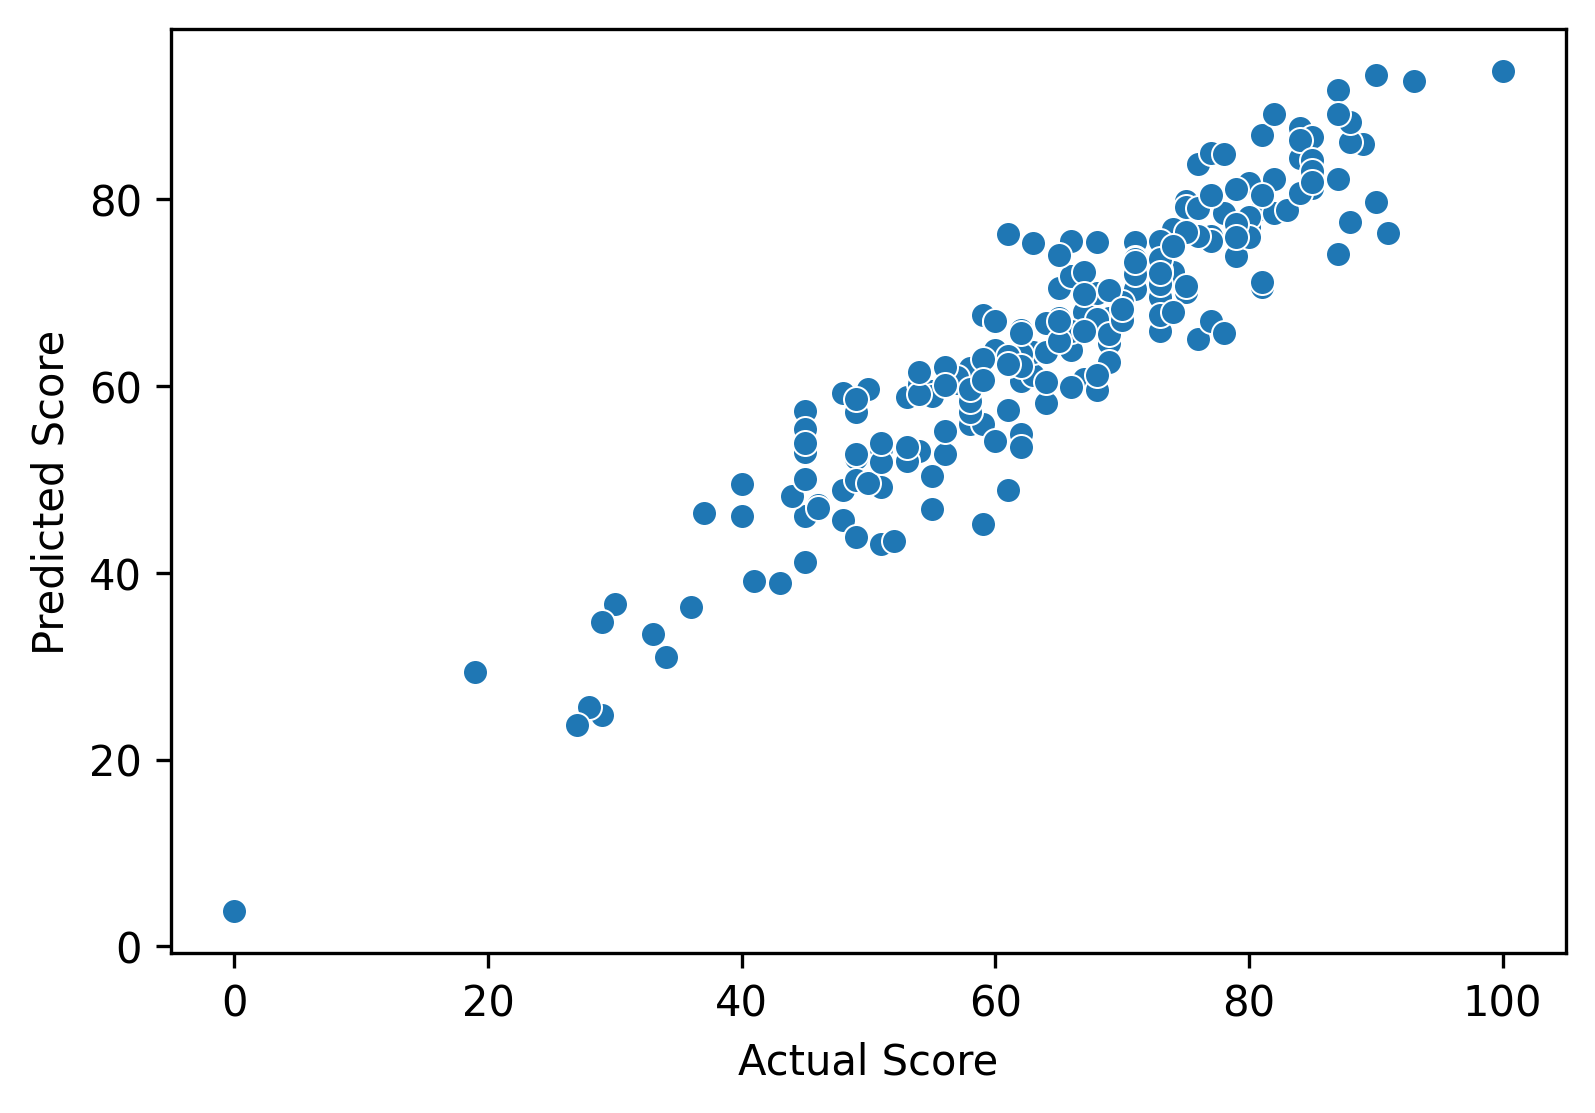

In [18]:
plt.figure(figsize=(6,4),dpi=300)

sns.scatterplot(x=y_test,y=y_pred)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score');

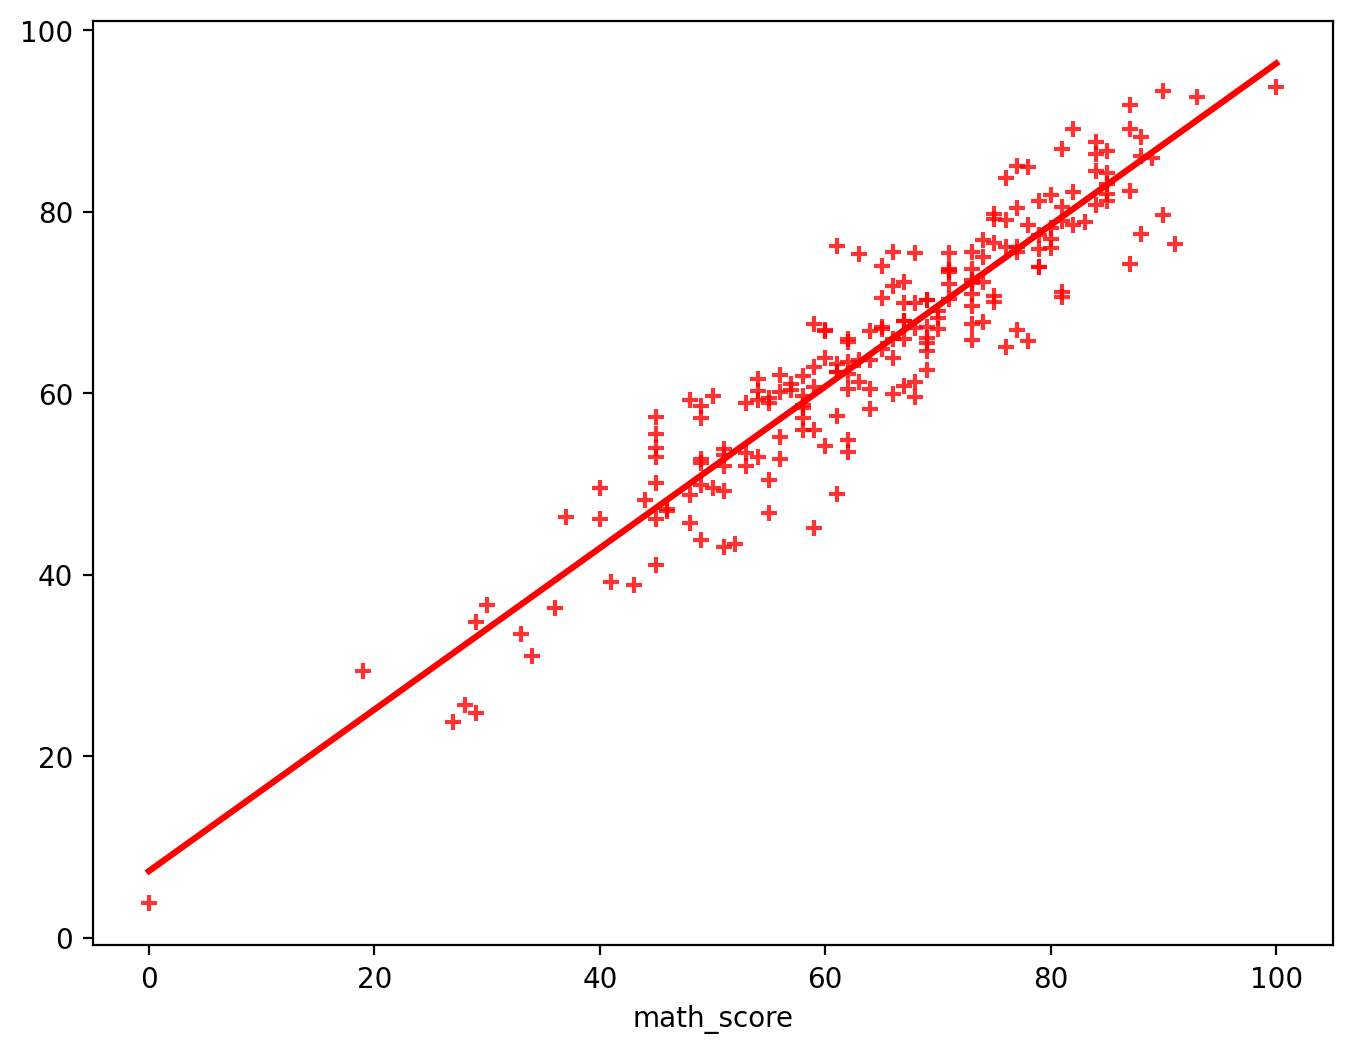

In [19]:
plt.figure(figsize=(8,6),dpi=200)

sns.regplot(x=y_test,y=y_pred,ci=None,color='red',marker='+');

In [20]:
pred_df=pd.DataFrame({'Actual Score':y_test,
                      'Predicted Score':y_pred,
                      'Difference':y_test-y_pred})
pred_df

,Actual Score,Predicted Score,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
